In [1]:
import numpy as np
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib
%matplotlib widget

def load_ims(datadir, inds):
    fns = np.sort(glob.glob(datadir+'*cube.fits'))
    # loading the data
    # NOTE. nothing with refpixels
    ims = np.array([fits.getdata(fn)[inds] for fn in fns])
    reset = np.mean(ims[:,0,:,:],axis=0)
    ims = ims[:,1:,:,:] - reset
    ims_flat = ims.copy()
    n_exp, n_read, ny, nx = ims.shape
    n_pix = ny*nx
    ims_flat.shape = (n_exp, n_read, n_pix)
    return ims_flat, ims, reset

# Use refactored version


Optimizer status 2: `ftol` termination condition is satisfied.
PTC fit results
  Gain       : 0.332 e⁻/DN
  Read noise : 3.207 DN  (1.065 e⁻)


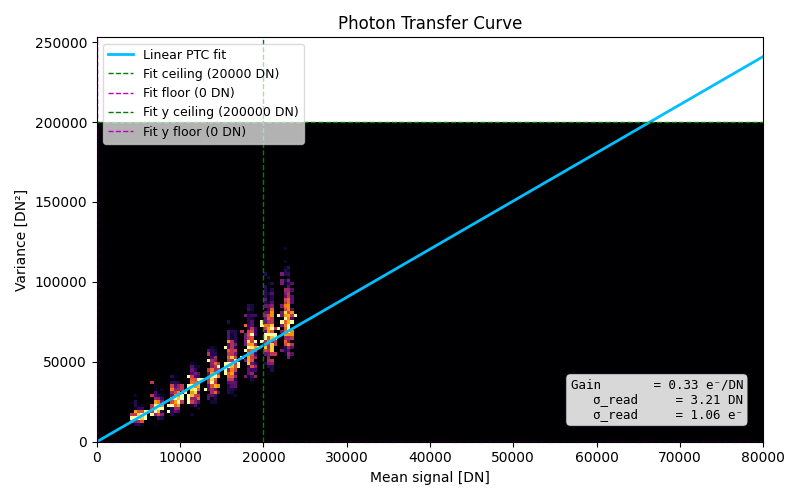

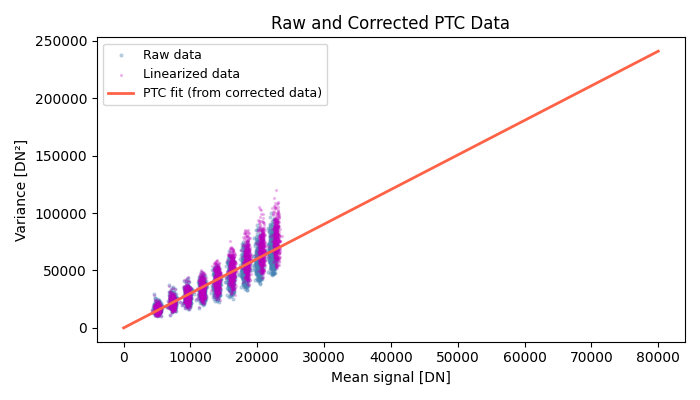

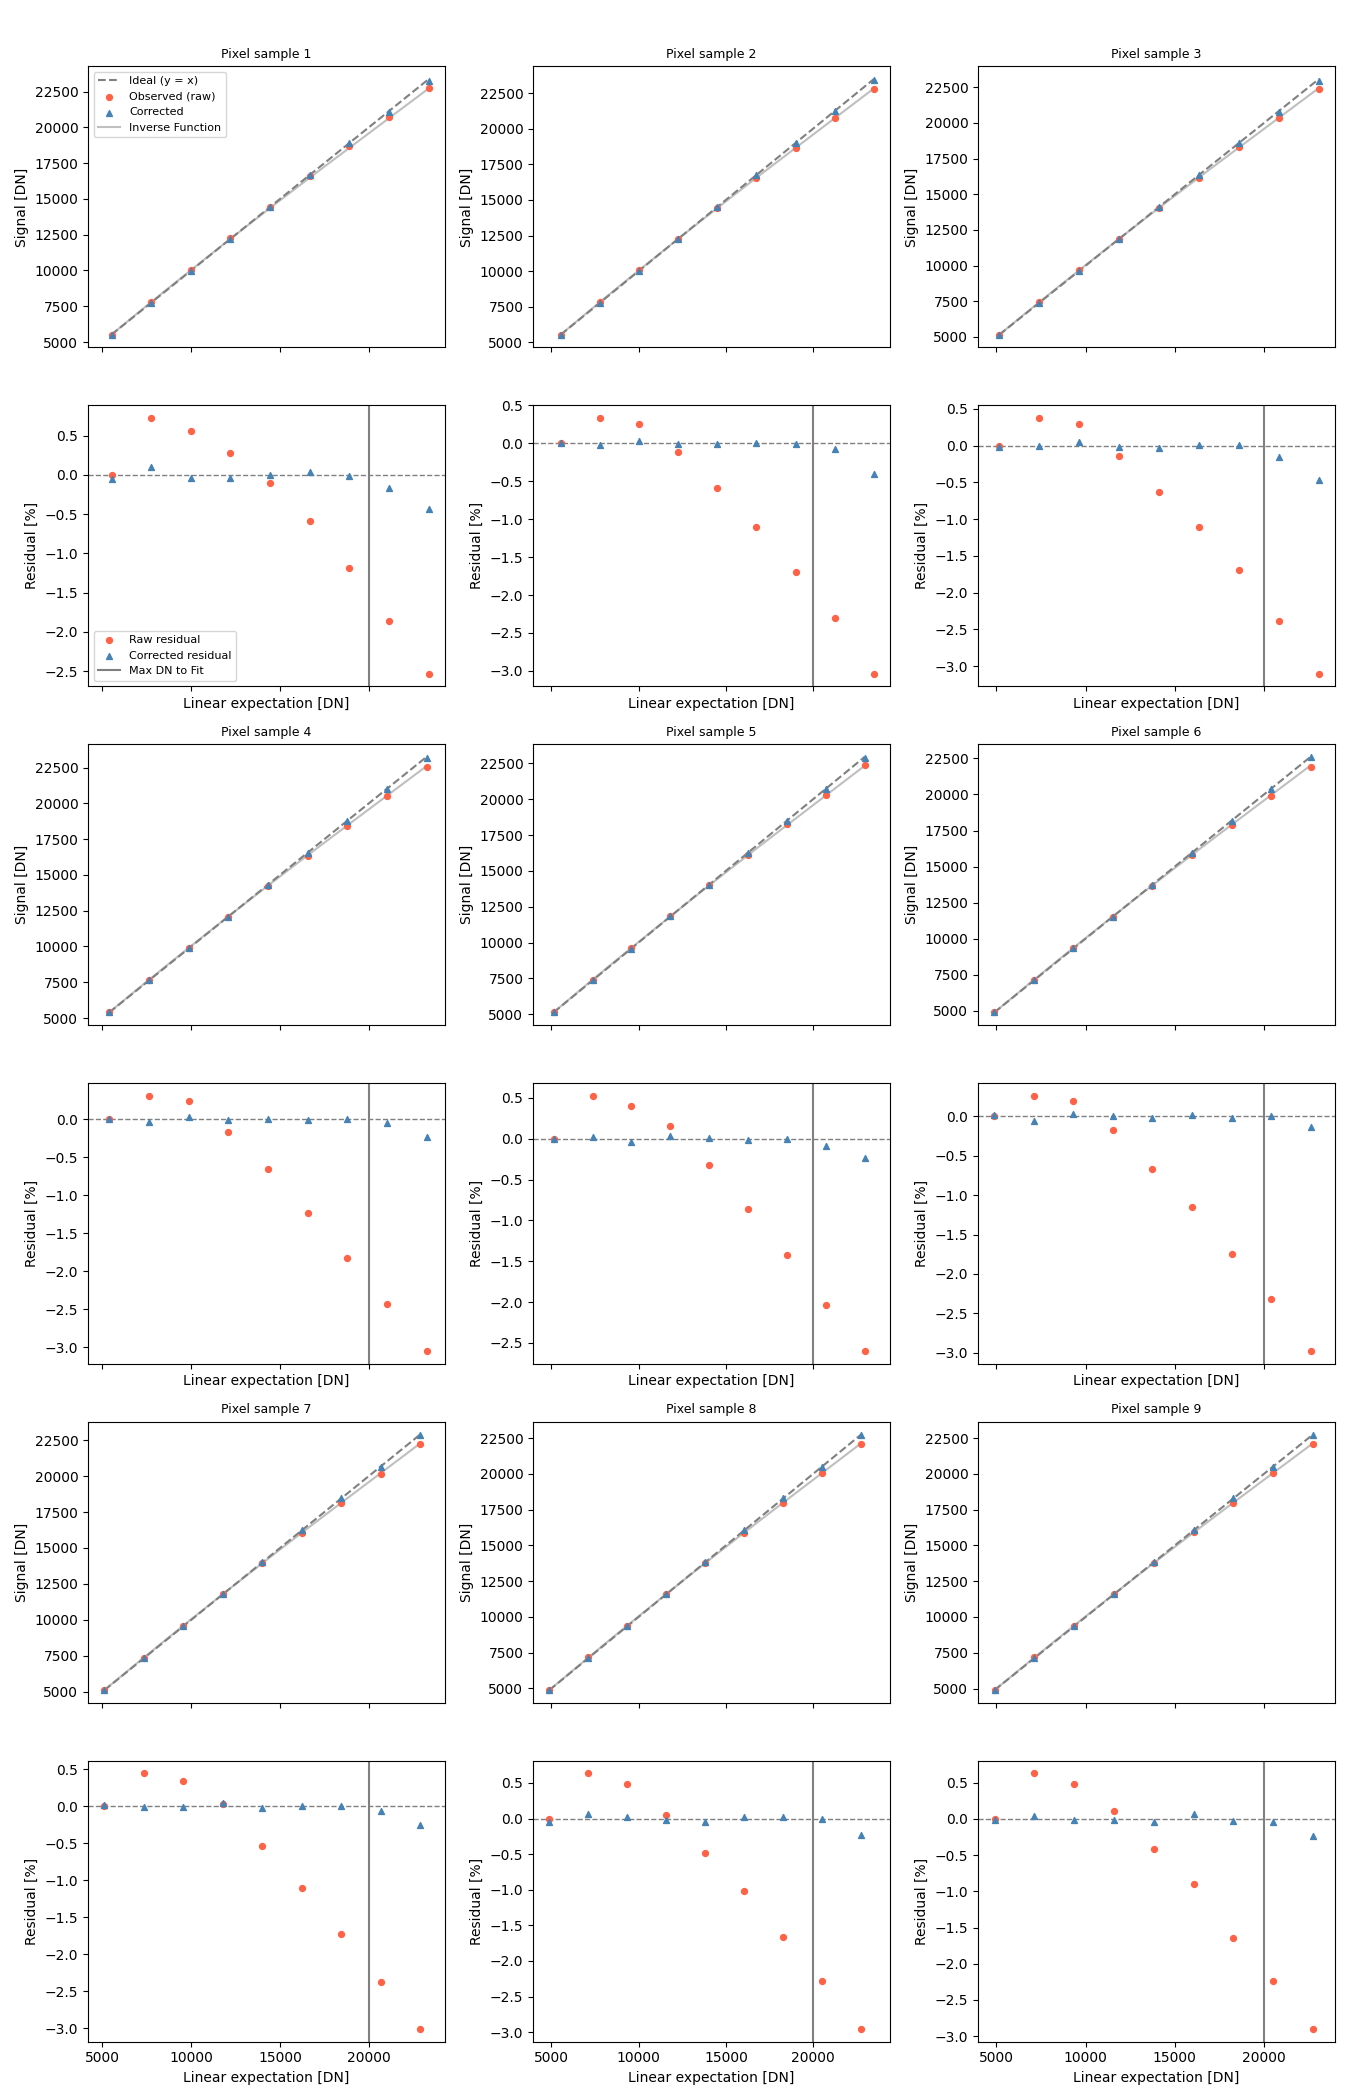

In [2]:
from ptc_gain import compute_ptc

# Load DATA
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260226/'
data_dir = 'utr_10reads/'
#DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260303/'
#data_dir = 'saturated_flats_UTR/'
min,max = 1050,1070
inds     = np.s_[:,min:max,min:max]
ims,ims_notflat,reset = load_ims(DATA_FOLDER + data_dir, inds)

# Run PTC
result = compute_ptc(ims, 
                     poly_degree=2,
                     fit_min_mean_dn= 0,
                     fit_min_var_dn2= 0,
                     fit_max_mean_dn=20_000, 
                     fit_max_var_dn2=200_000,
                     plot_max_mean_dn=80_000,
                     plot_max_var_dn2=200_000)


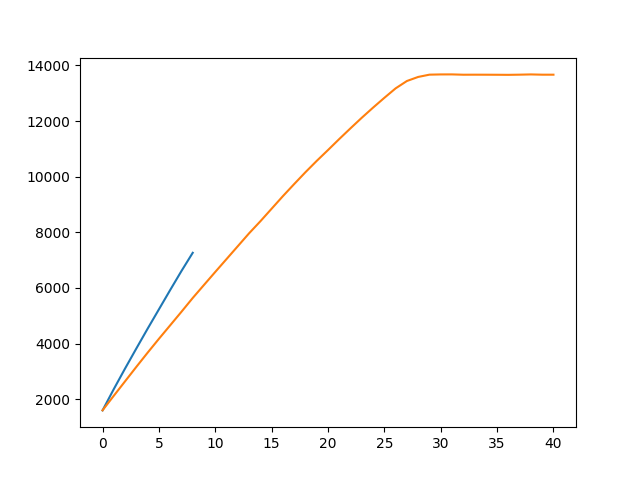

In [5]:

# plot ramp in electrons
plt.figure()
plt.plot(ims_notflat[0,:,10,10] * result.gain)

# load saturated files
DATA_FOLDER = '/Users/ashleybaker/Documents/HISPEC/_data/h2rg_images/20260303/'
data_dir = 'saturated_flats_UTR/'
min,max = 800,850
inds     = np.s_[:,min:max,min:max]
_,ims_notflat_sat,_ = load_ims(DATA_FOLDER + data_dir, inds)

plt.plot(ims_notflat_sat[0,:,10,10]* result.gain)


